In [1]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers,models
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import numpy as np

In [2]:
(x_train,_),(x_test,_)=keras.datasets.mnist.load_data()
print("Training images:",x_train.shape)
print("Testing images:",x_test.shape)

Training images: (60000, 28, 28)
Testing images: (10000, 28, 28)


In [3]:
x_train = x_train.astype("float32")/ 255.0
x_test = x_test.astype("float32")/ 255.0

In [4]:
x_train=np.expand_dims(x_train,axis=-1)
x_test=np.expand_dims(x_test,axis=-1)
print("Training image shape:",x_train.shape)

Training image shape: (60000, 28, 28, 1)


In [5]:
encoder=models.Sequential([
    layers.Input(shape=(28,28,1)),
    layers.Conv2D(
        32,
        (3,3),
        activation="relu",
        padding="same"
    ),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(
        64,
        (3,3),
        activation="relu",
        padding="same"
    ),
    layers.MaxPooling2D((2,2))

])

In [6]:
decoder=models.Sequential([
    
    layers.Conv2DTranspose(
        64,
        (3,3),
        strides=2,
        activation="relu",
        padding="same"
    ),
    
    
    layers.Conv2DTranspose(
        32,
        (3,3),
        strides=2,
        activation="relu",
        padding="same"
    ),
    layers.Conv2D(
        1,
        (3,3),
        activation="sigmoid",
        padding="same"
    )

])

In [7]:
autoencoder=models.Sequential([
    encoder,
    decoder
])

In [8]:
autoencoder.compile(
    optimizer="adam",
    loss="binary_crossentropy"
    
)

In [9]:
autoencoder.summary()
history= autoencoder.fit(
    x_train,
    x_train,
    epochs=5,
    batch_size=128,
    validation_data=(x_test,x_test)
)

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ sequential (Sequential)              │ (None, 7, 7, 64)            │          18,816 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ sequential_1 (Sequential)            │ (None, 28, 28, 1)           │          55,681 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 74,497 (291.00 KB)

 Trainable params: 74,497 (291.00 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 79s 155ms/step - loss: 0.1202 - val_loss: 0.0709
Epoch 2/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 81s 154ms/step - loss: 0.0694 - val_loss: 0.0675
Epoch 3/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 71s 152ms/step - loss: 0.0672 - val_loss: 0.0661
Epoch 4/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 71s 152ms/step - loss: 0.0661 - val_loss: 0.0652
Epoch 5/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 72s 154ms/step - loss: 0.0654 - val_loss: 0.0648


In [10]:
reconstructed=autoencoder.predict(x_test[:5])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 420ms/step


In [11]:
print("Minimum",reconstructed.min())
print("Maximum",reconstructed.max())
print("Mean",reconstructed.mean())

Minimum 5.151682e-10
Maximum 0.99644756
Mean 0.11279304


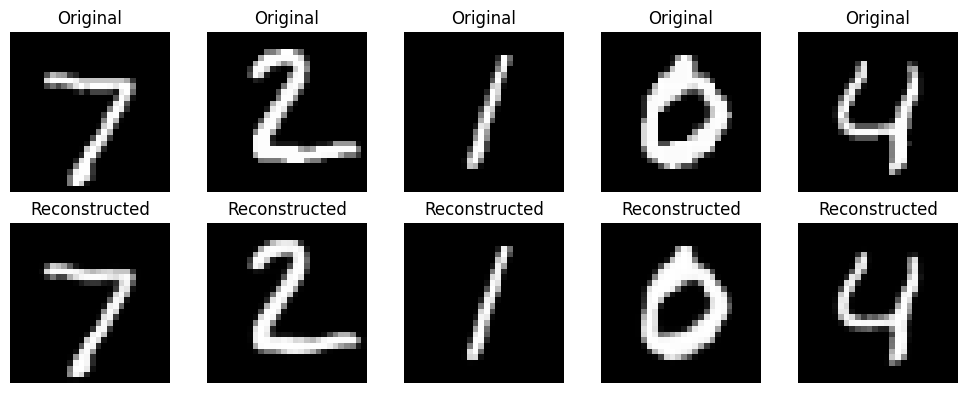

In [12]:
plt.figure(figsize=(10,4))

for i in range(5):
    plt.subplot(2,5,i+1)
    plt.imshow(x_test[i].squeeze(),cmap="gray")
    plt.axis("off")
    plt.title("Original")

    plt.subplot(2,5,i+6)
    plt.imshow(reconstructed[i].squeeze(),cmap="gray")
    plt.axis("off")
    plt.title("Reconstructed")

plt.tight_layout()
plt.show()